# DriftGuard — Incremental Gaussian Naive Bayes

## About This Notebook

In the previous notebooks, I established the baseline performance of Gaussian Naive Bayes and KNN and created a sequential stream from the ordered Electricity dataset.

In this notebook, I will focus on Gaussian Naive Bayes and convert it from a conventional batch-learning model into an incremental learning model.

The model will receive observations sequentially in batches and update its learned statistics as new data arrives instead of retraining from the beginning.

I will implement the running mean and variance updates using Welford's algorithm. This will provide the statistical foundation needed later for DriftGuard's adaptive Gaussian Naive Bayes model.

### What I Will Do

I will:

- Load the model-ready Electricity data
- Recreate the sequential batches
- Understand the statistics required by Gaussian Naive Bayes
- Implement Welford's  mean and variance updates
- Build an incremental Gaussian Naive Bayes classifier
- Validate the implementation against the standard Gaussian Naive Bayes model
- Evaluate its performance across the sequential stream

## Why Incremental Gaussian Naive Bayes?

### Why

A conventional Gaussian Naive Bayes model is normally trained using a fixed training dataset.

That approach is not ideal for a streaming environment because new observations become available continuously and the model should be able to learn from them without repeatedly retraining on the entire historical dataset.

For DriftGuard, I want Gaussian Naive Bayes to update its learned statistics as each new batch arrives.

### What Needs to Be Updated?

For each class and each numerical feature, Gaussian Naive Bayes needs statistics describing the feature distribution:

- Number of observations
- Mean
- Variance

For example, for one feature:

    UP class
    → count
    → mean
    → variance

    DOWN class
    → count
    → mean
    → variance

When new observations arrive, these statistics need to be updated efficiently.

## Welford's Algorithm

### Why

I need a numerically stable way to update the mean and variance as observations arrive one at a time.

A naive approach would repeatedly calculate the variance using all historical observations. That would require storing and processing the entire history again.

Welford's algorithm avoids this by maintaining only the running statistics needed for the update.

For a new observation `x`:

    count_new = count_old + 1

    mean_new = mean_old + (x - mean_old) / count_new

The running squared deviation is then updated using the new mean.

The variance can be obtained from the accumulated squared deviations.

### Why This Matters for DriftGuard

This allows Gaussian Naive Bayes to learn incrementally:

    New observation
          ↓
    Update count
          ↓
    Update mean
          ↓
    Update variance
          ↓
    Continue learning

The model does not need to retrain from scratch after every batch.

## Validating the Running Statistics

### Why

Before using Welford's algorithm inside the classifier, I want to verify that its running mean and variance agree with the standard batch calculations.

This isolates the statistical update logic from the rest of the machine-learning system.

If the running calculation is incorrect, the classifier built on top of it would also be incorrect.

In [1]:
# Import NumPy for numerical calculations
import numpy as np

# Create a small sequence for validating the running statistics
values = np.array([10.0, 12.0, 14.0, 20.0])

# Initialize the running count, mean, and squared deviation
count = 0
mean = 0.0
m2 = 0.0

# Update the running statistics one observation at a time
for value in values:
    count += 1
    difference = value - mean
    mean += difference / count
    updated_difference = value - mean
    m2 += difference * updated_difference

# Calculate the population variance from the running statistics
variance = m2 / count

# Calculate the same statistics directly for comparison
expected_mean = np.mean(values)
expected_variance = np.var(values)

# Display both results
print("Welford mean:", mean)
print("Standard mean:", expected_mean)
print("Welford variance:", variance)
print("Standard variance:", expected_variance)

Welford mean: 14.0
Standard mean: 14.0
Welford variance: 14.0
Standard variance: 14.0


## From Running Statistics to Incremental Learning

### Finding

The Welford calculation produced the same mean and variance as the standard NumPy calculation.

This confirms that the running statistics can be updated correctly one observation at a time.

### Decision

I will now use the reusable `RunningGaussianStats` implementation inside my incremental Gaussian Naive Bayes classifier.

The classifier will maintain separate statistics for each class and feature as new batches arrive.

In [7]:
%pip install -e "C:\Users\Pallavi Dahiya\drift_aware_classification"

Obtaining file:///C:/Users/Pallavi%20Dahiya/drift_aware_classification
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for drift_aware_classification (pyproject.toml): started
  Building editable for drift_aware_classification (pyproject.toml): finished with status 'done'
  Created wheel for drift_aware_classification: filename=drift_aware_classification-0.1.0-0.editable-py3-none-any.whl size=1484 sha256=d9071c85cc6ed9bbcf512d9120b94158a3324c56787fc4b3d7ce69e49e9048d9
  Stored in directory: C:\Users\Pallavi Dahiya\AppData\Loca

In [9]:
import sys

sys.path.insert(0, r"C:\Users\Pallavi Dahiya\drift_aware_classification\src")

In [10]:
from driftaware.models.incremental_gaussian_nb import IncrementalGaussianNB

In [13]:
import pandas as pd
import numpy as np

from driftaware.models.incremental_gaussian_nb import IncrementalGaussianNB
from scipy.io import arff

data, metadata = arff.loadarff(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\data\raw\elecNormNew.arff"
)

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)


Dataset shape: (45312, 9)


In [14]:
# Create a copy for model preparation
model_data = df.copy()

# Decode the day values from bytes into strings
model_data["day"] = model_data["day"].str.decode("utf-8")

# Decode the target values from bytes into strings
model_data["class"] = model_data["class"].str.decode("utf-8")

# Convert day categories into binary features
model_data = pd.get_dummies(
    model_data,
    columns=["day"],
    dtype=int
)

# Convert the target classes into numerical labels
model_data["class"] = model_data["class"].map({
    "DOWN": 0,
    "UP": 1
})

# Display the model-ready shape
print("Model-ready shape:", model_data.shape)

Model-ready shape: (45312, 15)


In [15]:
# Set the sequential batch size from Notebook 03
batch_size = 500

# Create an empty list for the sequential batches
batches = []

# Split the data without changing its original order
for start in range(0, len(model_data), batch_size):
    end = start + batch_size
    batches.append(model_data.iloc[start:end].copy())

# Display the streaming configuration
print("Number of batches:", len(batches))
print("First batch size:", len(batches[0]))
print("Final batch size:", len(batches[-1]))

Number of batches: 91
First batch size: 500
Final batch size: 312


## Initializing the Incremental Model

### Why

I now have the sequential batches and a tested incremental Gaussian Naive Bayes implementation.

Before evaluating the stream, I need to initialize the model with the number of predictor features.

I will use the first batch as a warm-up period so that the model has initial class and feature statistics before prequential evaluation begins.

In [16]:
# Separate the predictor columns from the target column
feature_columns = model_data.drop(columns=["class"]).columns

# Count the number of predictor features
n_features = len(feature_columns)

# Initialize the incremental Gaussian Naive Bayes model
model = IncrementalGaussianNB(
    n_features=n_features,
    classes=(0, 1)
)

# Display the number of features used by the model
print("Number of features:", n_features)

Number of features: 14


## Warming Up the Incremental Model

### Why

The first batch will be used to initialize the model's class counts, means, and variances.

I will not evaluate this batch because the model has not seen any data before it.

From the second batch onward, I will follow a prequential evaluation process: predict first, evaluate the predictions, and then update the model using the observed labels.

In [17]:
# Separate the first batch into predictors and target
X_warmup = batches[0].drop(columns=["class"])
y_warmup = batches[0]["class"]

# Update the model using the first batch
model.update(X_warmup, y_warmup)

# Display the number of observations learned from each class
print("Class 0 observations:", model.class_counts[0])
print("Class 1 observations:", model.class_counts[1])

# Display the total number of observations used for warm-up
print("Warm-up observations:", sum(model.class_counts.values()))

Class 0 observations: 271
Class 1 observations: 229
Warm-up observations: 500


## Prequential Evaluation Across the Stream

### Why

I now have an initialized incremental Gaussian Naive Bayes model.

For the remaining batches, I will evaluate the model before updating it with the current batch.

This follows a prequential evaluation strategy, which reflects how a real streaming system operates: the model first makes predictions on newly arriving data, and only afterward learns from the observed outcomes.

This also prevents the current batch labels from influencing its own predictions.

### What I Will Track

For each batch, I will record:

- Batch number
- Number of observations
- Accuracy
- F1 score
- Recall

These results will allow me to examine how model performance changes as the stream progresses.

In [18]:
# Import the evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Create an empty list to store batch-level results
streaming_results = []

# Process every batch after the warm-up batch
for batch_number, batch in enumerate(batches[1:], start=2):

    # Separate the current batch into predictors and target
    X_batch = batch.drop(columns=["class"])
    y_batch = batch["class"]

    # Predict before updating the model with the current batch
    predictions = model.predict(X_batch)

    # Calculate the evaluation metrics for the current batch
    accuracy = accuracy_score(y_batch, predictions)
    f1 = f1_score(y_batch, predictions)
    recall = recall_score(y_batch, predictions)

    # Store the current batch results
    streaming_results.append({
        "batch": batch_number,
        "observations": len(batch),
        "accuracy": accuracy,
        "f1": f1,
        "recall": recall
    })

    # Update the model only after evaluating the current batch
    model.update(X_batch, y_batch)

# Convert the collected results into a DataFrame
streaming_results = pd.DataFrame(streaming_results)

# Display the first few batch results
streaming_results.head()

,batch,observations,accuracy,f1,recall
0,2,500,0.668,0.694853,0.713208
1,3,500,0.376,0.324675,0.735294
2,4,500,0.748,0.590909,0.464286
3,5,500,0.616,0.360000,0.245455
4,6,500,0.814,0.713846,0.607330


In [19]:
# Display the number of evaluated batches
print("Evaluated batches:", len(streaming_results))

# Display the total number of evaluated observations
print("Evaluated observations:", streaming_results["observations"].sum())

# Display the final batch number
print("Final evaluated batch:", streaming_results["batch"].iloc[-1])

Evaluated batches: 90
Evaluated observations: 44812
Final evaluated batch: 91


## Summarizing the Streaming Performance

### Finding

The incremental model successfully processed all 90 post-warm-up batches without changing the original order of the stream.

I will now calculate the overall performance across all evaluated observations.

I will use observation-level weighting rather than simply averaging the batch scores, because the final batch contains only 312 observations while the other batches contain 500.

In [20]:
# Calculate the total number of evaluated observations
total_observations = streaming_results["observations"].sum()

# Calculate the observation-weighted accuracy across all batches
weighted_accuracy = (
    streaming_results["accuracy"] * streaming_results["observations"]
).sum() / total_observations

# Calculate the observation-weighted F1 score across all batches
weighted_f1 = (
    streaming_results["f1"] * streaming_results["observations"]
).sum() / total_observations

# Calculate the observation-weighted recall across all batches
weighted_recall = (
    streaming_results["recall"] * streaming_results["observations"]
).sum() / total_observations

# Create a summary table for the streaming experiment
streaming_summary = pd.DataFrame({
    "metric": ["Accuracy", "F1", "Recall"],
    "score": [
        weighted_accuracy,
        weighted_f1,
        weighted_recall
    ]
})

# Display the overall streaming performance
streaming_summary

,metric,score
0,Accuracy,0.714072
1,F1,0.511556
2,Recall,0.453325


In [22]:
# Define the directory where experiment results will be stored
results_dir = "reports/results"

# Create the results directory if it does not already exist
import os
os.makedirs(results_dir, exist_ok=True)

# Save the batch-level streaming results
streaming_results.to_csv(
    os.path.join(results_dir, "incremental_nb_streaming_results.csv"),
    index=False
)

# Save the overall streaming performance
streaming_summary.to_csv(
    os.path.join(results_dir, "incremental_nb_streaming_summary.csv"),
    index=False
)

# Confirm that both result files were saved
print("Streaming results saved successfully.")

Streaming results saved successfully.


### Decision

The incremental Gaussian Naive Bayes model can now be evaluated not only by its overall streaming performance but also by how its performance changes across the stream.

This batch-level view is important because a single overall metric can hide periods where the data distribution changes and the model's performance deteriorates.

In the next section, I will visualize the batch-level performance across the sequential stream.

## Visualizing Performance Across the Stream

### Why

Overall metrics summarize the model's performance, but they can hide changes that occur at specific points in the stream.

I will visualize accuracy, F1 score, and recall for each sequential batch to see how the incremental model behaves over time.

These performance changes will later provide context for the drift detection and adaptation experiments.

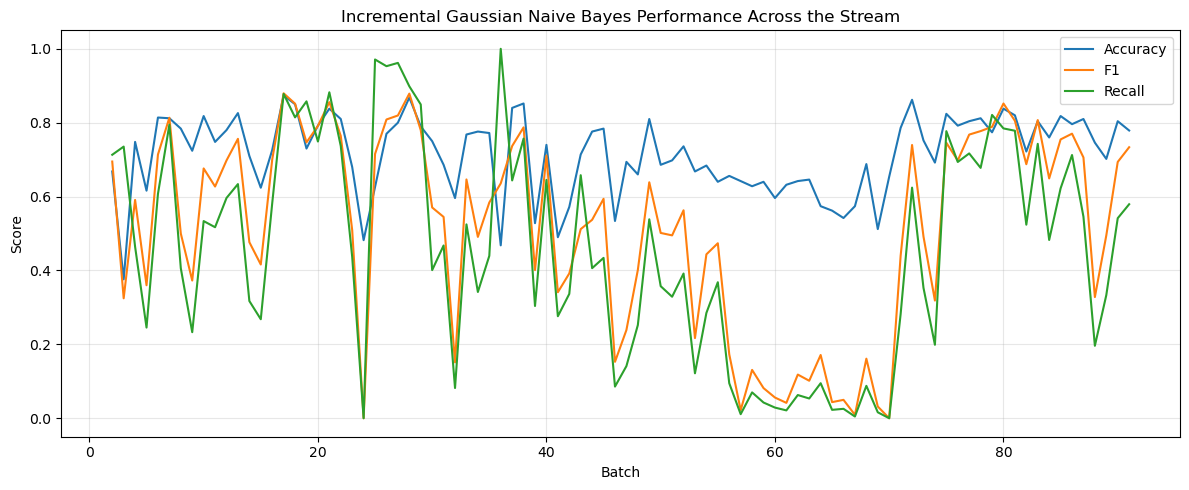

In [23]:
# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Create a figure for the batch-level performance
plt.figure(figsize=(12, 5))

# Plot accuracy across the sequential batches
plt.plot(
    streaming_results["batch"],
    streaming_results["accuracy"],
    label="Accuracy"
)

# Plot F1 score across the sequential batches
plt.plot(
    streaming_results["batch"],
    streaming_results["f1"],
    label="F1"
)

# Plot recall across the sequential batches
plt.plot(
    streaming_results["batch"],
    streaming_results["recall"],
    label="Recall"
)

# Add labels and a title to the plot
plt.xlabel("Batch")
plt.ylabel("Score")
plt.title("Incremental Gaussian Naive Bayes Performance Across the Stream")

# Display the legend
plt.legend()

# Add a light grid to make batch-level changes easier to inspect
plt.grid(alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()

In [25]:
# Create the figures directory if it does not already exist
import os
os.makedirs("reports/figures", exist_ok=True)

# Save the current figure
plt.savefig(
    "reports/figures/incremental_nb_streaming_performance.png",
    dpi=300,
    bbox_inches="tight"
)

# Confirm that the figure was saved
print("Figure saved successfully.")

Figure saved successfully.


<Figure size 640x480 with 0 Axes>

## Conclusion

In this notebook, I converted Gaussian Naive Bayes from a conventional batch-learning approach into an incremental learning approach suitable for sequential data.

I first validated Welford's algorithm and confirmed that its running mean and variance matched the standard NumPy calculations. I then moved this logic into a reusable `RunningGaussianStats` component and verified it with unit tests.

I built the `IncrementalGaussianNB` classifier using these running statistics and validated the classifier with a separate unit test.

For the streaming experiment, I used the sequential batches established in Notebook 03. I treated the first batch as a warm-up period and evaluated the remaining batches using prequential evaluation: predict first, evaluate the predictions, and then update the model using the observed labels.

The resulting batch-level metrics show how the model behaves as new observations arrive over time. This is more informative for a non-stationary stream than looking only at one static test score.

### Decision

This incremental Gaussian Naive Bayes model will serve as the **non-adaptive streaming baseline** for the remainder of the project.

I will not introduce drift detection or drift-triggered adaptation at this stage. Those components will be evaluated separately so that I can determine whether explicit drift handling provides a measurable improvement over continuous incremental learning alone.

### Next Phase

In the next notebook, I will implement a **windowed KNN** model. Unlike Gaussian Naive Bayes, KNN does not maintain statistical summaries. Instead, it will retain a bounded window of recent observations, allowing me to study how a memory-based model behaves under the same sequential stream.